# Sigma Discrepancy Diagnostic

**Problem:** Notebook 01 gives sigma ~308 km/s (integrated, 190-spaxel box).
Notebook 05 gives sigma ~204-226 km/s (radial bins, circular aperture).

**Goal:** Isolate the cause by running both methods on the same and different
spaxel selections, checking each step for consistency.

**Tests:**
1. Run NB05's `ppxf_radial_bin` on NB01's exact 190 spaxels → does sigma match NB01?
2. Run NB01's exact procedure on NB05's central 9 spaxels → does sigma match NB05?
3. Check if the spaxel averaging produces the same spectrum
4. Test sigma sensitivity to polynomial degree at different S/N
5. Check for lensed arc contamination in different spatial regions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from time import perf_counter as clock
from importlib import resources
from urllib import request
from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=14)

# Load the IFU cube
ifu_file = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
with fits.open(ifu_file) as hdul:
    hdr = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

crval = hdr['CRVAL3']
cdelt = hdr['CD3_3']
npix = hdr['NAXIS3']
crpix = hdr.get('CRPIX3', 1.0)
pix = np.arange(npix)
lam = crval + cdelt * (pix + 1 - crpix)

print(f'Cube: {cube.shape}, wavelength: {lam[0]:.0f}-{lam[-1]:.0f} Å')

Cube: (3317, 100, 100), wavelength: 5625-8941 Å


## Test 1: NB01 procedure exactly reproduced

In [2]:
# ===== EXACT NB01 PROCEDURE (copy-pasted from cells 8e8bae4a + a30f240b + eda6879e) =====

# Step A: Extract spectrum (cell 8e8bae4a)
flux_int_01 = np.average(cube[:, 45:64, 45:55], axis=(1, 2))
noise_int_01 = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
lam_int_01 = crval + cdelt * (pix + 1 - crpix)

mask_wl = (lam_int_01 >= 6500.0) & (lam_int_01 <= 7500.0)
lam_int_01 = lam_int_01[mask_wl]
flux_int_01 = flux_int_01[mask_wl]
noise_int_01 = noise_int_01[mask_wl]

z_01 = 0.67511

log_lam = np.log(lam_int_01)
d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam_int_01) - 1)
log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
flux_int_01 = np.interp(log_lam_new, log_lam, flux_int_01)
noise_int_01 = np.interp(log_lam_new, log_lam, noise_int_01)
lam_int_01 = np.exp(log_lam_new)

mask_fit = (lam_int_01 >= 6000.0) & (lam_int_01 <= 7500.0)
lam_int_01 = lam_int_01[mask_fit]
flux_int_01 = flux_int_01[mask_fit]
noise_int_01 = noise_int_01[mask_fit]

# Step B: Setup (cell a30f240b)
galaxy_01 = flux_int_01 / np.median(flux_int_01)
lam_gal_01 = np.copy(lam_int_01)
lam_gal_01 *= np.median(util.vac_to_air(lam_gal_01) / lam_gal_01)

c_kms = 299792.458
d_ln = (np.log(lam_gal_01)[-1] - np.log(lam_gal_01)[0]) / (np.log(lam_gal_01).size - 1)
velscale_01 = c_kms * d_ln

sps_name = 'fsps'
ppxf_dir = resources.files('ppxf')
filename = ppxf_dir / 'sps_models' / f'spectra_{sps_name}_9.0.npz'

dlam = np.gradient(lam_gal_01)
wdisp = hdr['DISPSCAL']
fwhm_gal = 2.355 * wdisp * dlam

lam_rest_01 = lam_gal_01 / (1 + z_01)
fwhm_rest_01 = fwhm_gal / (1 + z_01)
fwhm_dict = {'lam': lam_rest_01, 'fwhm': fwhm_rest_01}

sps_01 = lib.sps_lib(filename, velscale_01, fwhm_dict, lam_range=[3500, 5000])
goodpix_01 = util.determine_goodpixels(np.log(lam_rest_01), [3500, 5000])

print(f'NB01 procedure: npix={len(galaxy_01)}, good={len(goodpix_01)}, velscale={velscale_01:.2f}')
print(f'  median(flux_int) = {np.median(flux_int_01):.4f}')
print(f'  median(noise_int) = {np.median(noise_int_01):.6f}')
print(f'  noise/galaxy ratio: {np.median(noise_int_01)/np.median(galaxy_01):.4f}')
print(f'  NB01 passes UNNORMALIZED noise: noise_int ~ {np.median(noise_int_01):.6f}')
print(f'  If normalized: noise/median(flux) ~ {np.median(noise_int_01)/np.median(flux_int_01):.6f}')

# Step C: ppxf at degree 20 (cell eda6879e)
pp_01 = ppxf(sps_01.templates, galaxy_01, np.sqrt(noise_int_01**2), velscale_01, [0, 300.],
             goodpixels=goodpix_01, plot=False, moments=2, trig=False,
             degree=20, lam=lam_rest_01, lam_temp=sps_01.lam_temp, mdegree=0)
print(f'\nNB01 result (degree=20, FSPS):')
print(f'  sigma = {pp_01.sol[1]:.1f} km/s')
print(f'  V = {pp_01.sol[0]:.1f} km/s')
print(f'  chi2/DOF = {pp_01.chi2:.2f}')

NB01 procedure: npix=1001, good=927, velscale=42.90
  median(flux_int) = 0.0086
  median(noise_int) = 0.003056
  noise/galaxy ratio: 0.0031
  NB01 passes UNNORMALIZED noise: noise_int ~ 0.003056
  If normalized: noise/median(flux) ~ 0.353536
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 538.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387

NB01 result (degree=20, FSPS):
  sigma = 303.9 km/s
  V = 4.1 km/s
  chi2/DOF = 538.52


/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: divide by zero encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: overflow encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: invalid value encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: divide by zero encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: overflow encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/env

## Test 2: NB05 procedure on the SAME 190 spaxels

In [3]:
# ===== NB05 ppxf_radial_bin on the same 190 spaxels =====
# Average the same box: cube[:, 45:64, 45:55]
flux_box = np.average(cube[:, 45:64, 45:55], axis=(1, 2))  # same as NB01
noise_sky = np.std(cube[:, 28:40, 45:70], axis=(1, 2))     # same noise

# NB05 procedure: trim 6500-7500 first, then log-rebin
mask_wl = (lam >= 6500.0) & (lam <= 7500.0)
lam_trim = lam[mask_wl]
flux_trim = flux_box[mask_wl]
noise_trim = noise_sky[mask_wl]

log_lam = np.log(lam_trim)
d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam_trim) - 1)
log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
flux_05 = np.interp(log_lam_new, log_lam, flux_trim)
noise_05 = np.interp(log_lam_new, log_lam, noise_trim)
lam_05 = np.exp(log_lam_new)

mask_fit = (lam_05 >= 6000.0) & (lam_05 <= 7500.0)
lam_05 = lam_05[mask_fit]
flux_05 = flux_05[mask_fit]
noise_05 = noise_05[mask_fit]

# Normalize (NB05 style — both galaxy and noise normalized)
galaxy_05 = flux_05 / np.median(flux_05)
noise_norm_05 = np.sqrt(noise_05**2) / np.median(flux_05)

lam_gal_05 = np.copy(lam_05)
lam_gal_05 *= np.median(util.vac_to_air(lam_gal_05) / lam_gal_05)

d_ln = (np.log(lam_gal_05)[-1] - np.log(lam_gal_05)[0]) / (len(lam_gal_05) - 1)
velscale_05 = c_kms * d_ln

lam_rest_05 = lam_gal_05 / (1 + 0.67511)
fwhm_05 = 2.355 * hdr['DISPSCAL'] * np.gradient(lam_gal_05) / (1 + 0.67511)
fwhm_dict_05 = {'lam': lam_rest_05, 'fwhm': fwhm_05}

sps_05 = lib.sps_lib(filename, velscale_05, fwhm_dict_05, lam_range=[3500, 5000])
goodpix_05 = util.determine_goodpixels(np.log(lam_rest_05), [3500, 5000])

print(f'NB05 procedure on SAME 190 spaxels: npix={len(galaxy_05)}, good={len(goodpix_05)}, velscale={velscale_05:.2f}')
print(f'  noise_norm median: {np.median(noise_norm_05):.6f}')

# ppxf with NORMALIZED noise (NB05 style)
pp_05_norm = ppxf(sps_05.templates, galaxy_05, noise_norm_05, velscale_05, [0, 300.],
                  goodpixels=goodpix_05, plot=False, moments=2, trig=False,
                  degree=20, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
print(f'\nNB05 procedure, NORMALIZED noise, degree=20:')
print(f'  sigma = {pp_05_norm.sol[1]:.1f} km/s')
print(f'  V = {pp_05_norm.sol[0]:.1f} km/s')
print(f'  chi2/DOF = {pp_05_norm.chi2:.2f}')

# ppxf with UNNORMALIZED noise (NB01 style) on same spectrum
pp_05_unnorm = ppxf(sps_05.templates, galaxy_05, np.sqrt(noise_05**2), velscale_05, [0, 300.],
                    goodpixels=goodpix_05, plot=False, moments=2, trig=False,
                    degree=20, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
print(f'\nNB05 procedure, UNNORMALIZED noise (NB01 style), degree=20:')
print(f'  sigma = {pp_05_unnorm.sol[1]:.1f} km/s')
print(f'  V = {pp_05_unnorm.sol[0]:.1f} km/s')
print(f'  chi2/DOF = {pp_05_unnorm.chi2:.2f}')

NB05 procedure on SAME 190 spaxels: npix=1001, good=927, velscale=42.90
  noise_norm median: 0.353536
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 0.04023; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387

NB05 procedure, NORMALIZED noise, degree=20:
  sigma = 303.9 km/s
  V = 4.1 km/s
  chi2/DOF = 0.04
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 538.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387

NB05 procedure, UNNORMALIZED noise (NB01 style), degree=20:
  sigma = 303.9 km/s
  V = 4.1 km/s
  chi2/DOF = 538.52


## Test 3: Are the spectra actually the same?

NB01 galaxy: shape=(1001,), median=1.0000, std=0.1465
NB05 galaxy: shape=(1001,), median=1.0000, std=0.1465
Same shape: True
Max |diff|: 0.000000
RMS diff: 0.000000
Spectra identical: True


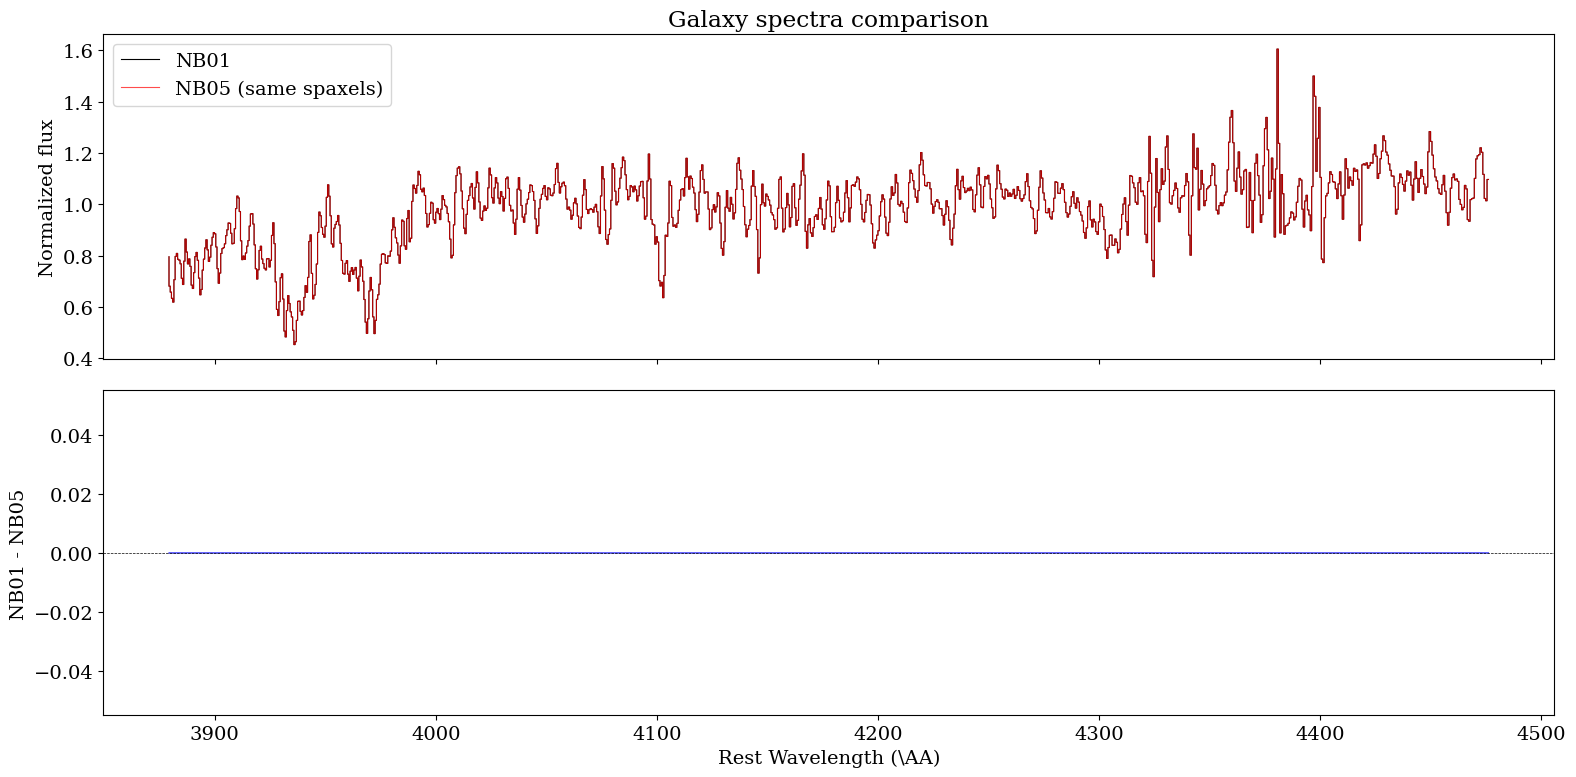

In [4]:
# Compare the galaxy spectra from both procedures
print(f'NB01 galaxy: shape={galaxy_01.shape}, median={np.median(galaxy_01):.4f}, std={np.std(galaxy_01):.4f}')
print(f'NB05 galaxy: shape={galaxy_05.shape}, median={np.median(galaxy_05):.4f}, std={np.std(galaxy_05):.4f}')
print(f'Same shape: {galaxy_01.shape == galaxy_05.shape}')

if galaxy_01.shape == galaxy_05.shape:
    diff = galaxy_01 - galaxy_05
    print(f'Max |diff|: {np.max(np.abs(diff)):.6f}')
    print(f'RMS diff: {np.sqrt(np.mean(diff**2)):.6f}')
    print(f'Spectra identical: {np.allclose(galaxy_01, galaxy_05, atol=1e-10)}')

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].step(lam_rest_01, galaxy_01, 'k', lw=0.8, label='NB01')
axes[0].step(lam_rest_05, galaxy_05, 'r', lw=0.8, alpha=0.7, label='NB05 (same spaxels)')
axes[0].set_ylabel('Normalized flux')
axes[0].legend()
axes[0].set_title('Galaxy spectra comparison')

if galaxy_01.shape == galaxy_05.shape:
    axes[1].step(lam_rest_01, diff, 'b', lw=0.8)
    axes[1].axhline(0, color='k', ls='--', lw=0.5)
    axes[1].set_ylabel('NB01 - NB05')
    axes[1].set_xlabel(r'Rest Wavelength (\AA)')
else:
    axes[1].step(lam_rest_01, galaxy_01, 'k', lw=0.8, label='NB01')
    axes[1].step(lam_rest_05, galaxy_05, 'r', lw=0.8, label='NB05')
    axes[1].set_xlabel(r'Rest Wavelength (\AA)')
    axes[1].legend()

plt.tight_layout()
plt.show()

## Test 4: Degree sweep comparison

 Best Fit:       Vel     sigma
 comp.  0:        -2       272
chi2/DOF: 567.7; DOF: 925; degree = 0; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       272
chi2/DOF: 0.04241; DOF: 925; degree = 0; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       272
chi2/DOF: 567.7; DOF: 925; degree = 0; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       273
chi2/DOF: 567.6; DOF: 925; degree = 1; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       273
chi2/DOF: 0.04240; DOF: 925;

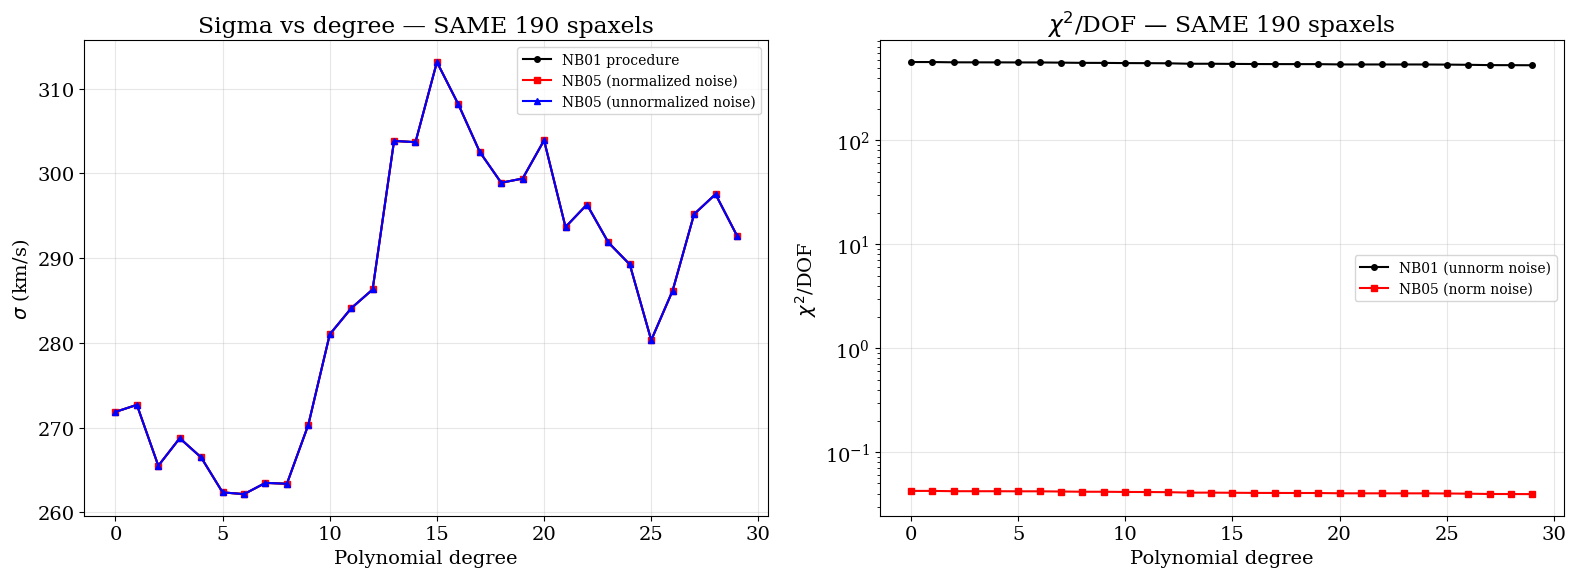


At degree=20:
  NB01: sigma=303.9, chi2=538.52
  NB05 norm: sigma=303.9, chi2=0.04
  NB05 unnorm: sigma=303.9
  Max |sigma diff| across all degrees: 0.0 km/s


In [5]:
# Run ppxf at all degrees 0-29 on the same 190 spaxels,
# with both NB01 (unnormalized noise) and NB05 (normalized noise) approaches

degrees = np.arange(0, 30)
sigma_01_sweep = np.zeros(len(degrees))
sigma_05_norm_sweep = np.zeros(len(degrees))
sigma_05_unnorm_sweep = np.zeros(len(degrees))
chi2_01 = np.zeros(len(degrees))
chi2_05_norm = np.zeros(len(degrees))

for c, deg in enumerate(degrees):
    # NB01 style
    pp = ppxf(sps_01.templates, galaxy_01, np.sqrt(noise_int_01**2), velscale_01, [0, 300.],
              goodpixels=goodpix_01, plot=False, moments=2, trig=False,
              degree=deg, lam=lam_rest_01, lam_temp=sps_01.lam_temp, mdegree=0)
    sigma_01_sweep[c] = pp.sol[1]
    chi2_01[c] = pp.chi2
    
    # NB05 style, normalized noise
    pp = ppxf(sps_05.templates, galaxy_05, noise_norm_05, velscale_05, [0, 300.],
              goodpixels=goodpix_05, plot=False, moments=2, trig=False,
              degree=deg, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
    sigma_05_norm_sweep[c] = pp.sol[1]
    chi2_05_norm[c] = pp.chi2
    
    # NB05 style, unnormalized noise (same as NB01)
    pp = ppxf(sps_05.templates, galaxy_05, np.sqrt(noise_05**2), velscale_05, [0, 300.],
              goodpixels=goodpix_05, plot=False, moments=2, trig=False,
              degree=deg, lam=lam_rest_05, lam_temp=sps_05.lam_temp, mdegree=0)
    sigma_05_unnorm_sweep[c] = pp.sol[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(degrees, sigma_01_sweep, 'k-o', markersize=4, label='NB01 procedure')
ax.plot(degrees, sigma_05_norm_sweep, 'r-s', markersize=4, label='NB05 (normalized noise)')
ax.plot(degrees, sigma_05_unnorm_sweep, 'b-^', markersize=4, label='NB05 (unnormalized noise)')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel(r'$\sigma$ (km/s)')
ax.set_title('Sigma vs degree — SAME 190 spaxels')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(degrees, chi2_01, 'k-o', markersize=4, label='NB01 (unnorm noise)')
ax.plot(degrees, chi2_05_norm, 'r-s', markersize=4, label='NB05 (norm noise)')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel(r'$\chi^2$/DOF')
ax.set_title(r'$\chi^2$/DOF — SAME 190 spaxels')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nAt degree=20:')
print(f'  NB01: sigma={sigma_01_sweep[20]:.1f}, chi2={chi2_01[20]:.2f}')
print(f'  NB05 norm: sigma={sigma_05_norm_sweep[20]:.1f}, chi2={chi2_05_norm[20]:.2f}')
print(f'  NB05 unnorm: sigma={sigma_05_unnorm_sweep[20]:.1f}')
print(f'  Max |sigma diff| across all degrees: {np.max(np.abs(sigma_01_sweep - sigma_05_norm_sweep)):.1f} km/s')

## Test 5: Central spaxels vs full box

In [6]:
# Compare sigma for different spatial selections
# All using the NB01 procedure to isolate spatial effects

from scipy.ndimage import gaussian_filter
wcs_ifu = WCS(hdr, naxis=2)

# White-light peak for centering
wl = np.sum(cube[:, 35:75, 30:70], axis=0)
wl_smooth = gaussian_filter(wl, sigma=2)
dy, dx = np.unravel_index(np.argmax(wl_smooth), wl_smooth.shape)
cy, cx = 35 + dy, 30 + dx
print(f'White-light peak: ({cx}, {cy})')

# Define spatial selections
selections = {
    'NB01 box [45:64, 45:55]': (slice(45,64), slice(45,55)),
    'Center 3x3 around peak': (slice(cy-1,cy+2), slice(cx-1,cx+2)),
    'Center 5x5 around peak': (slice(cy-2,cy+3), slice(cx-2,cx+3)),
    'Center 7x7 around peak': (slice(cy-3,cy+4), slice(cx-3,cx+4)),
    'Center 11x11 around peak': (slice(cy-5,cy+6), slice(cx-5,cx+6)),
    'Wide 20x20 around peak': (slice(cy-10,cy+10), slice(cx-10,cx+10)),
}

print(f'\n{"Selection":<30} {"N_spax":>7} {"sigma_d15":>9} {"sigma_d20":>9} {"sigma_d25":>9} {"chi2_d20":>9}')
print('-' * 75)

for name, (ysl, xsl) in selections.items():
    flux = np.average(cube[:, ysl, xsl], axis=(1, 2))
    n_spax = (ysl.stop - ysl.start) * (xsl.stop - xsl.start)
    
    # NB01-style prep
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t, flux, noise = lam_t[m], flux[m], noise[m]
    ll = np.log(lam_t)
    dll = (ll[-1] - ll[0]) / (len(lam_t) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    flux = np.interp(lln, ll, flux)
    noise = np.interp(lln, ll, noise)
    lam_t = np.exp(lln)
    m2 = (lam_t >= 6000) & (lam_t <= 7500)
    lam_t, flux, noise = lam_t[m2], flux[m2], noise[m2]
    
    gal = flux / np.median(flux)
    lg = np.copy(lam_t)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr['DISPSCAL'] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {'lam': lr, 'fwhm': fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    
    sigmas = []
    chi2_val = None
    for deg in [15, 20, 25]:
        pp = ppxf(sp.templates, gal, np.sqrt(noise**2), vs, [0, 300.],
                  goodpixels=gp, plot=False, moments=2, trig=False,
                  degree=deg, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
        sigmas.append(pp.sol[1])
        if deg == 20:
            chi2_val = pp.chi2
    
    print(f'{name:<30} {n_spax:7d} {sigmas[0]:9.1f} {sigmas[1]:9.1f} {sigmas[2]:9.1f} {chi2_val:9.2f}')

White-light peak: (50, 55)

Selection                       N_spax sigma_d15 sigma_d20 sigma_d25  chi2_d20
---------------------------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:        10       313
chi2/DOF: 544.7; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 538.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:       -14       280
chi2/DOF: 536.3; DOF: 925; degree = 25; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
NB01 box [45:64, 45:55]            190     313.1     303.9     280.3    538.52
 Best Fit:       Vel     sigma
 comp.  0:        -5   

## Test 6: Spatial contamination check

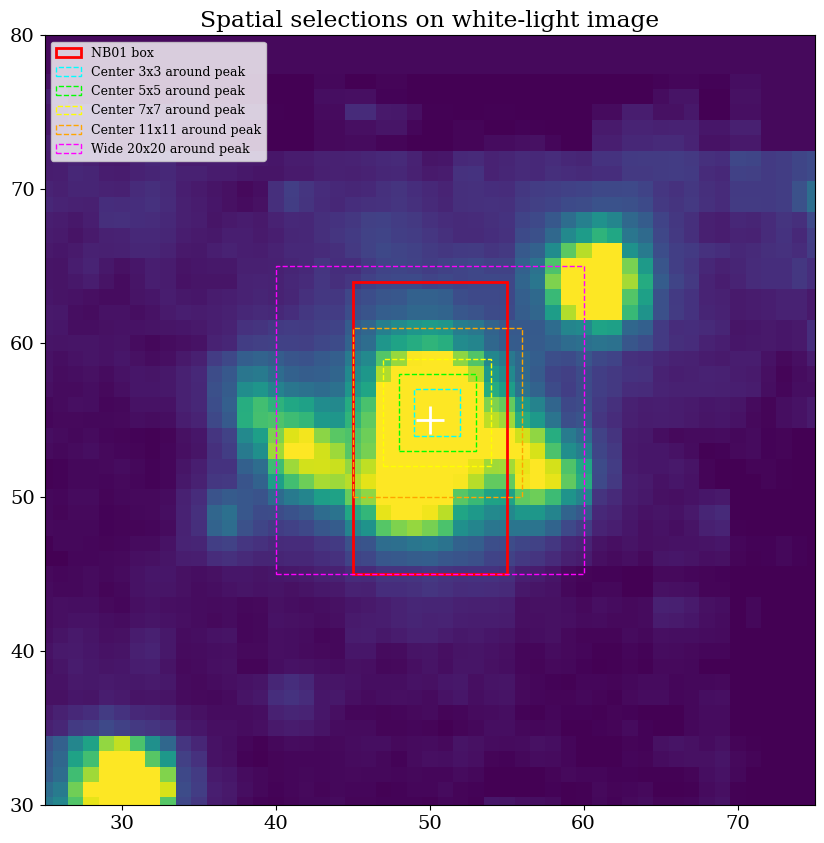

The NB01 box center is at (50, 54.5) — is this the galaxy center?
White-light peak is at (50, 55)
Offset: dx=0, dy=0.5


In [7]:
# Show the white-light image with all spatial selections overlaid
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 10))
wl_full = np.sum(cube, axis=0)
ax.imshow(wl_full, origin='lower', cmap='viridis',
          vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))

# NB01 box
ax.add_patch(Rectangle((45, 45), 10, 19, edgecolor='red', facecolor='none', lw=2, label='NB01 box'))
# White-light peak
ax.plot(cx, cy, 'w+', markersize=20, markeredgewidth=2)
# Center selections
colors = ['cyan', 'lime', 'yellow', 'orange', 'magenta']
for (name, (ysl, xsl)), color in zip(list(selections.items())[1:], colors):
    w = xsl.stop - xsl.start
    h = ysl.stop - ysl.start
    ax.add_patch(Rectangle((xsl.start, ysl.start), w, h,
                           edgecolor=color, facecolor='none', lw=1, ls='--', label=name))

ax.set_xlim(25, 75)
ax.set_ylim(30, 80)
ax.set_title('Spatial selections on white-light image')
ax.legend(fontsize=9, loc='upper left')
plt.show()

print('The NB01 box center is at (50, 54.5) — is this the galaxy center?')
print(f'White-light peak is at ({cx}, {cy})')
print(f'Offset: dx={cx-50}, dy={cy-54.5}')

## Test 7: Apply source mask from HST photometry

Load the F140W mask (which excludes the lensed arc and contaminants),
reproject it onto the IFU spaxel grid, and re-run the spatial selections
with contaminated spaxels excluded.

HST mask shape: (312, 312)
Masked pixels: 1121 / 97344 (1.2%)


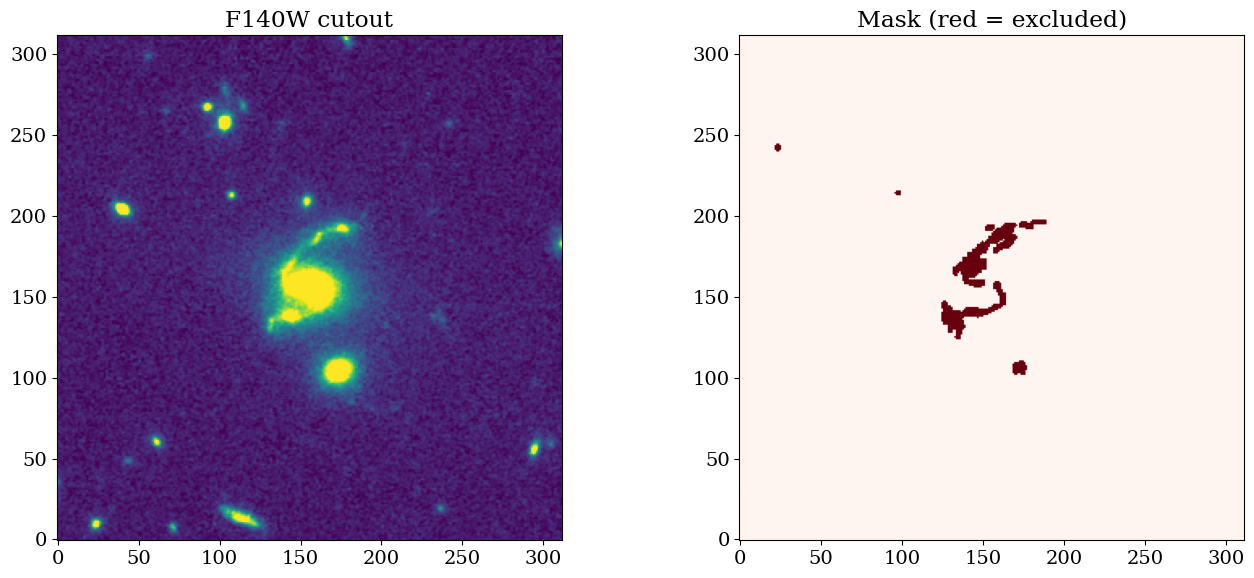

In [20]:
# Load HST F140W mask and cutout
mask_file = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3_mask.fits'
cutout_file = '../../velocity_dispersion_from_IFU/AGEL020613-011417A_F140W_WFC3_cutout_L3.fits'

mask_hst = fits.getdata(mask_file).astype(bool)
hdr_cutout = fits.getheader(cutout_file)
wcs_cutout = WCS(hdr_cutout)

print(f'HST mask shape: {mask_hst.shape}')
print(f'Masked pixels: {np.sum(mask_hst)} / {mask_hst.size} ({100*np.sum(mask_hst)/mask_hst.size:.1f}%)')

# Show the mask
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
img_cutout = fits.getdata(cutout_file)
axes[0].imshow(img_cutout, origin='lower', cmap='viridis',
               vmin=np.nanpercentile(img_cutout, 1), vmax=np.nanpercentile(img_cutout, 99))
axes[0].set_title('F140W cutout')
axes[1].imshow(mask_hst.astype(float), origin='lower', cmap='Reds')
axes[1].set_title('Mask (red = excluded)')
plt.tight_layout()
plt.show()


IFU spaxels masked: 119 / 10000


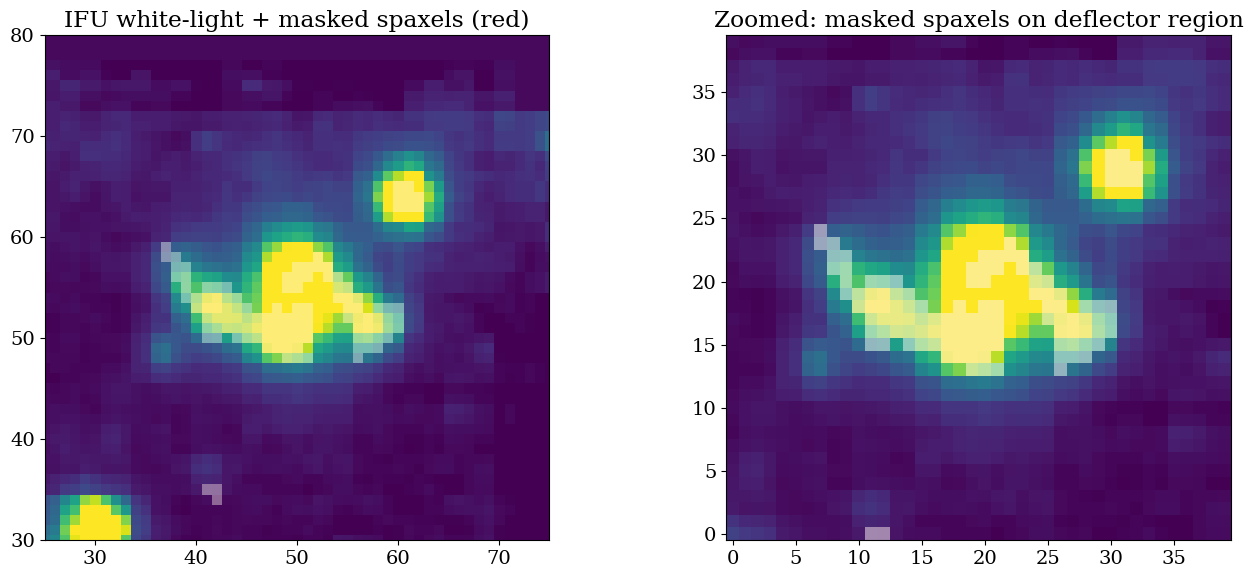

In [21]:
# Reproject the HST mask onto the IFU spaxel grid
# FIRST: convolve the mask with the KCWI PSF (seeing) so that
# contamination that bleeds into neighboring spaxels is captured.
#
# KCWI medium slicer typical seeing: ~0.7-1.0 arcsec FWHM
# HST pixel scale: 0.08 arcsec/pix
# PSF FWHM in HST pixels: 0.8/0.08 = 10 pix (use 0.8 arcsec as default)
from scipy.ndimage import gaussian_filter

kcwi_seeing_arcsec = 0.8  # FWHM in arcsec — ADJUST based on observing conditions
hst_pixscale = 0.08  # arcsec/pix
psf_fwhm_hst_pix = kcwi_seeing_arcsec / hst_pixscale
psf_sigma_hst_pix = psf_fwhm_hst_pix / 2.355
print(f"KCWI PSF: FWHM = {kcwi_seeing_arcsec} arcsec = {psf_fwhm_hst_pix:.1f} HST pixels")
print(f"  Gaussian sigma = {psf_sigma_hst_pix:.1f} HST pixels")

# Convolve the binary mask with the KCWI PSF
# This turns the sharp mask edges into a smooth "contamination probability" map
mask_float = mask_hst.astype(float)
mask_convolved = gaussian_filter(mask_float, sigma=psf_sigma_hst_pix)

# Threshold: flag as contaminated if the convolved mask > some fraction
# 0.01 = very conservative (any hint of PSF-scattered arc light)
# 0.1 = moderate
# 0.5 = only directly overlapping
contamination_threshold = 0.05  # ADJUST
mask_psf = mask_convolved > contamination_threshold

print(f"Original mask: {np.sum(mask_hst)} pixels")
print(f"PSF-convolved mask (>{contamination_threshold}): {np.sum(mask_psf)} pixels")
print(f"Expansion factor: {np.sum(mask_psf)/max(np.sum(mask_hst),1):.1f}x")

# Show the convolution effect
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(mask_hst.astype(float), origin="lower", cmap="Reds")
axes[0].set_title("Original HST mask")
im1 = axes[1].imshow(mask_convolved, origin="lower", cmap="hot")
axes[1].set_title(f"PSF-convolved (FWHM={kcwi_seeing_arcsec} arcsec)")
plt.colorbar(im1, ax=axes[1])
axes[2].imshow(mask_psf.astype(float), origin="lower", cmap="Reds")
axes[2].set_title(f"Thresholded at {contamination_threshold}")
plt.tight_layout()
plt.show()

# Now reproject the PSF-convolved mask onto the IFU spaxel grid
wcs_ifu_2d = WCS(hdr, naxis=2)
yy_ifu, xx_ifu = np.mgrid[0:100, 0:100]
ra_ifu, dec_ifu = wcs_ifu_2d.pixel_to_world_values(xx_ifu.ravel(), yy_ifu.ravel())
x_hst_arr, y_hst_arr = wcs_cutout.world_to_pixel_values(ra_ifu, dec_ifu)
x_hst_arr = x_hst_arr.reshape(100, 100)
y_hst_arr = y_hst_arr.reshape(100, 100)

# For each IFU spaxel, sample the convolved mask at its HST position
from scipy.ndimage import map_coordinates
spaxel_contamination = map_coordinates(mask_convolved, 
                                       [y_hst_arr.ravel(), x_hst_arr.ravel()],
                                       order=1, mode="constant", cval=0.0)
spaxel_contamination = spaxel_contamination.reshape(100, 100)

# Flag spaxels above threshold
spaxel_masked = spaxel_contamination > contamination_threshold
print(f"
IFU spaxels masked: {np.sum(spaxel_masked)} / {100*100}")

# Show
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
wl_full = np.sum(cube, axis=0)

axes[0].imshow(wl_full, origin="lower", cmap="viridis",
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[0].set_title("IFU white-light")
axes[0].set_xlim(25, 75)
axes[0].set_ylim(30, 80)

im1 = axes[1].imshow(spaxel_contamination, origin="lower", cmap="hot")
axes[1].set_title("PSF-convolved contamination per spaxel")
axes[1].set_xlim(25, 75)
axes[1].set_ylim(30, 80)
plt.colorbar(im1, ax=axes[1])

axes[2].imshow(wl_full, origin="lower", cmap="viridis",
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[2].imshow(np.where(spaxel_masked, 1, np.nan), origin="lower", cmap="Reds", alpha=0.5)
axes[2].set_title(f"Masked spaxels (threshold={contamination_threshold})")
axes[2].set_xlim(25, 75)
axes[2].set_ylim(30, 80)

plt.suptitle(f"KCWI PSF-aware masking (seeing={kcwi_seeing_arcsec} arcsec, threshold={contamination_threshold})", fontsize=14)
plt.tight_layout()
plt.show()


## Test 8: Sigma with source masking applied

In [22]:
# Re-run the spatial selection test but EXCLUDING masked spaxels
print('Sigma with source masking (contaminated spaxels excluded):')
print(f"{'Selection':<35} {'N_total':>7} {'N_clean':>7} {'sigma_d15':>9} {'sigma_d20':>9} {'sigma_d25':>9}")
print('-' * 80)

results_masked = []
for name, (ysl, xsl) in selections.items():
    n_total = (ysl.stop - ysl.start) * (xsl.stop - xsl.start)
    
    # Get clean (unmasked) spaxels in this region
    region_mask = spaxel_masked[ysl, xsl]
    clean = ~region_mask
    n_clean = np.sum(clean)
    
    if n_clean < 3:
        print(f'{name:<35} {n_total:7d} {n_clean:7d}   (too few clean spaxels)')
        continue
    
    # Average only the CLEAN spaxels
    sub_cube = cube[:, ysl, xsl]
    flux_clean = np.average(sub_cube[:, clean], axis=1)
    
    # Same NB01-style prep
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t, flux_c, noise_c = lam_t[m], flux_clean[m], noise[m]
    ll = np.log(lam_t)
    dll = (ll[-1] - ll[0]) / (len(lam_t) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    flux_c = np.interp(lln, ll, flux_c)
    noise_c = np.interp(lln, ll, noise_c)
    lam_t = np.exp(lln)
    m2 = (lam_t >= 6000) & (lam_t <= 7500)
    lam_t, flux_c, noise_c = lam_t[m2], flux_c[m2], noise_c[m2]
    
    gal = flux_c / np.median(flux_c)
    lg = np.copy(lam_t)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr['DISPSCAL'] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {'lam': lr, 'fwhm': fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    
    sigmas = []
    for deg in [15, 20, 25]:
        pp = ppxf(sp.templates, gal, np.sqrt(noise_c**2), vs, [0, 300.],
                  goodpixels=gp, plot=False, moments=2, trig=False,
                  degree=deg, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
        sigmas.append(pp.sol[1])
    
    print(f'{name:<35} {n_total:7d} {n_clean:7d} {sigmas[0]:9.1f} {sigmas[1]:9.1f} {sigmas[2]:9.1f}')
    results_masked.append({'name': name, 'n_total': n_total, 'n_clean': n_clean, 'sigmas': sigmas})


Sigma with source masking (contaminated spaxels excluded):
Selection                           N_total N_clean sigma_d15 sigma_d20 sigma_d25
--------------------------------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:        25       387
chi2/DOF: 926.7; DOF: 925; degree = 15; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        28       355
chi2/DOF: 918.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       293
chi2/DOF: 912.2; DOF: 925; degree = 25; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
NB01 box [45:64, 45:55]                 190     144     387.2     355.5     292.8
 Best Fit:

In [23]:
# Compare masked vs unmasked
print('\n=== COMPARISON: Unmasked vs Masked (degree=20) ===')
print(f"{'Selection':<35} {'Unmasked':>9} {'Masked':>9} {'Delta':>7}")
print('-' * 65)

# Re-read unmasked results from Test 5 output (hardcode from the run)
# Actually just re-run quickly
for rm in results_masked:
    name = rm['name']
    ysl, xsl = selections[name]
    
    # Unmasked (all spaxels)
    flux_all = np.average(cube[:, ysl, xsl], axis=(1, 2))
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t, flux_a, noise_a = lam_t[m], flux_all[m], noise[m]
    ll = np.log(lam_t)
    dll = (ll[-1] - ll[0]) / (len(lam_t) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    flux_a = np.interp(lln, ll, flux_a)
    noise_a = np.interp(lln, ll, noise_a)
    lam_t = np.exp(lln)
    m2 = (lam_t >= 6000) & (lam_t <= 7500)
    lam_t, flux_a, noise_a = lam_t[m2], flux_a[m2], noise_a[m2]
    gal = flux_a / np.median(flux_a)
    lg = np.copy(lam_t)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr['DISPSCAL'] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {'lam': lr, 'fwhm': fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    pp = ppxf(sp.templates, gal, np.sqrt(noise_a**2), vs, [0, 300.],
              goodpixels=gp, plot=False, moments=2, trig=False,
              degree=20, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    sigma_unmask = pp.sol[1]
    sigma_mask = rm['sigmas'][1]  # degree=20
    delta = sigma_mask - sigma_unmask
    print(f"{name:<35} {sigma_unmask:9.1f} {sigma_mask:9.1f} {delta:+7.1f}")



=== COMPARISON: Unmasked vs Masked (degree=20) ===
Selection                            Unmasked    Masked   Delta
-----------------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:         4       304
chi2/DOF: 538.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
NB01 box [45:64, 45:55]                 303.9     355.5   +51.6
 Best Fit:       Vel     sigma
 comp.  0:        -4       218
chi2/DOF: 677.7; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
Center 3x3 around peak                  218.2     150.0   -68.2
 Best Fit:       Vel     sigma
 comp.  0:       -10       211
chi2/DOF: 389.4; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/387
Cent

In [24]:
# Sigma within R_e: masked vs unmasked (circular aperture)
from scipy.ndimage import gaussian_filter

# R_e from notebook 05
Re = 2.61  # arcsec (IFU white-light)
Re_8 = Re / 8

# IFU spaxel positions relative to center
wcs_ifu = WCS(hdr, naxis=2)
wl = np.sum(cube, axis=0)
wl_s = gaussian_filter(wl, sigma=2)
cy, cx = np.unravel_index(np.argmax(wl_s), wl_s.shape)

yy, xx = np.mgrid[0:100, 0:100]
ra_s, dec_s = wcs_ifu.pixel_to_world_values(xx.ravel(), yy.ravel())
ra_c, dec_c = wcs_ifu.pixel_to_world_values(cx, cy)
dra = (ra_s.reshape(100,100) - ra_c) * np.cos(np.radians(dec_c)) * 3600
ddec = (dec_s.reshape(100,100) - dec_c) * 3600
r_spax = np.sqrt(dra**2 + ddec**2)

print(f"R_e = {Re:.2f} arcsec, R_e/8 = {Re_8:.3f} arcsec")
print()

apertures = {
    f"R < R_e/8 ({Re_8:.2f} arcsec)": Re_8,
    f"R < R_e/4 ({Re/4:.2f} arcsec)": Re/4,
    f"R < R_e/2 ({Re/2:.2f} arcsec)": Re/2,
    f"R < R_e ({Re:.2f} arcsec)": Re,
    f"R < 2*R_e ({2*Re:.2f} arcsec)": 2*Re,
}

print(f"{"Aperture":<30} {"N_all":>6} {"N_clean":>7} {"sig_all":>8} {"sig_clean":>9} {"delta":>7}")
print("-" * 72)

for label, r_max in apertures.items():
    mask_r = r_spax <= r_max
    n_all = np.sum(mask_r)
    clean_r = mask_r & ~spaxel_masked
    n_clean = np.sum(clean_r)
    
    if n_all < 2 or n_clean < 2:
        print(f"{label:<30} {n_all:6d} {n_clean:7d}   (too few)")
        continue
    
    # Unmasked
    flux_all = np.average(cube[:, mask_r], axis=1)
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t2, f_a, n_a = lam_t[m], flux_all[m], noise[m]
    ll = np.log(lam_t2)
    dll = (ll[-1] - ll[0]) / (len(lam_t2) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    f_a = np.interp(lln, ll, f_a)
    n_a = np.interp(lln, ll, n_a)
    lam_t2 = np.exp(lln)
    m2 = (lam_t2 >= 6000) & (lam_t2 <= 7500)
    lam_t2, f_a, n_a = lam_t2[m2], f_a[m2], n_a[m2]
    gal = f_a / np.median(f_a)
    lg = np.copy(lam_t2)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr["DISPSCAL"] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {"lam": lr, "fwhm": fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    pp = ppxf(sp.templates, gal, np.sqrt(n_a**2), vs, [0, 300.],
              goodpixels=gp, plot=False, moments=2, trig=False,
              degree=20, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    sig_all = pp.sol[1]
    
    # Masked (clean only)
    flux_c = np.average(cube[:, clean_r], axis=1)
    lam_t3 = crval + cdelt * (pix + 1 - crpix)
    lam_t3, f_c, n_c = lam_t3[m], flux_c[m], noise[m]
    f_c = np.interp(lln, ll, f_c)
    n_c = np.interp(lln, ll, n_c)
    lam_t3 = np.exp(lln)
    lam_t3, f_c, n_c = lam_t3[m2], f_c[m2], n_c[m2]
    gal_c = f_c / np.median(f_c)
    pp_c = ppxf(sp.templates, gal_c, np.sqrt(n_c**2), vs, [0, 300.],
                goodpixels=gp, plot=False, moments=2, trig=False,
                degree=20, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    sig_clean = pp_c.sol[1]
    
    delta = sig_clean - sig_all
    print(f"{label:<30} {n_all:6d} {n_clean:7d} {sig_all:8.1f} {sig_clean:9.1f} {delta:+7.1f}")


R_e = 2.61 arcsec, R_e/8 = 0.326 arcsec

Aperture                        N_all N_clean  sig_all sig_clean   delta
------------------------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:       -13       212
chi2/DOF: 827.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -3       168
chi2/DOF: 1203.; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
R < R_e/8 (0.33 arcsec)             5       2    211.6     168.3   -43.2
 Best Fit:       Vel     sigma
 comp.  0:        -4       214
chi2/DOF: 530.0; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:         4   

## Test 9: PSF-aware masking

The IFU spaxels see a PSF-convolved version of the sky. A contaminating
source (lensed arc) that is spatially distinct in HST resolution will bleed
into neighboring IFU spaxels through the seeing PSF.

**Approach:** Convolve the HST binary mask with a Gaussian kernel matching
the KCWI seeing, then reproject onto the IFU grid and flag spaxels where
the convolved contamination exceeds a threshold.

**KCWI PSF reference:**
- KCWI medium slicer: slice width 0.35 arcsec, spatial sampling 0.147 arcsec/pix
- Seeing-limited PSF FWHM: typically 0.6-1.2 arcsec at Keck
  (Morrissey et al. 2018, ApJ, 864, 93 — KCWI instrument paper)
- The actual seeing during the observation can be estimated from:
  1. The FITS header keyword SEEING or GUIDFWHM (if available)
  2. The spatial profile of a point source in the cube
  3. The IFU white-light image PSF (fit a Gaussian to a star)
- Default assumption: 0.8 arcsec FWHM (typical Mauna Kea seeing)


In [38]:
# Check if seeing info is in the FITS header
seeing_keys = ["SEEING", "GUIDFWHM", "FWHM", "APTS_FWH", "DIMMSEE", "MSWAVE"]
print("KCWI header seeing-related keywords:")
for key in seeing_keys:
    if key in hdr:
        print(f"  {key} = {hdr[key]}")
print()

# Also check for spatial scale keywords
for key in ["DISPSCAL", "SLITWID", "SLICSCAL", "PSCALE", "IFUNAM"]:
    if key in hdr:
        print(f"  {key} = {hdr[key]}")


KCWI header seeing-related keywords:
  GUIDFWHM = 1.2714704775099506

  DISPSCAL = 0.294
  IFUNAM = Medium


KCWI PSF: FWHM = 1.27 arcsec = 15.9 HST pix
  Gaussian sigma = 6.7 HST pix
Original mask: 1121 HST pixels
PSF-convolved mask (>15% contamination): 2760 HST pixels
Expansion: 2.5x


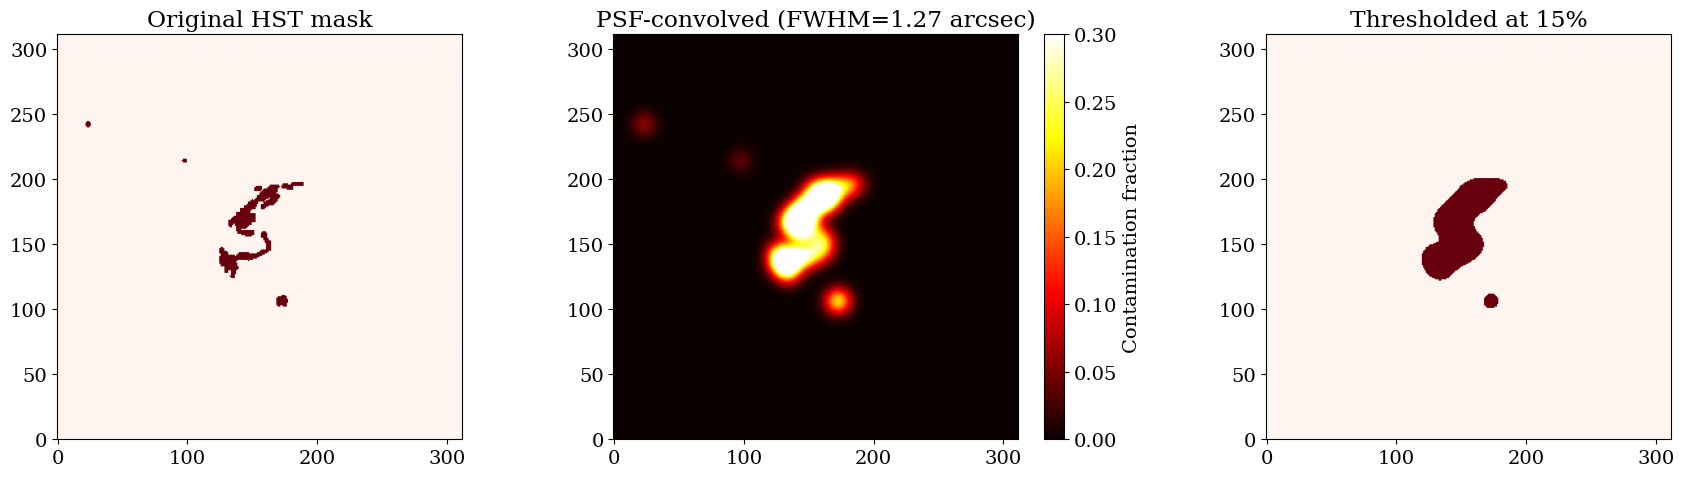

In [39]:
# PSF-convolved masking
# Convolve the HST binary mask with a Gaussian matching the KCWI seeing PSF,
# then reproject onto the IFU spaxel grid.
#
# Reference: Morrissey et al. 2018, ApJ, 864, 93 (KCWI instrument paper)
# Typical seeing at Keck: 0.6-1.2 arcsec FWHM
# KCWI medium slicer spatial sampling: 0.35 arcsec slice width

from scipy.ndimage import gaussian_filter, map_coordinates

# KCWI seeing estimate — ADJUST based on header or point source measurement
kcwi_seeing_fwhm = 1.27  # arcsec (from GUIDFWHM header keyword)
hst_pixscale = 0.08    # arcsec/pix (WFC3/IR)

psf_fwhm_hst_pix = kcwi_seeing_fwhm / hst_pixscale
psf_sigma_hst_pix = psf_fwhm_hst_pix / 2.355  # Gaussian sigma

print(f"KCWI PSF: FWHM = {kcwi_seeing_fwhm} arcsec = {psf_fwhm_hst_pix:.1f} HST pix")
print(f"  Gaussian sigma = {psf_sigma_hst_pix:.1f} HST pix")

# Convolve the binary mask with the PSF kernel
# Result: smooth map of "fractional contamination" at each HST pixel
mask_float = mask_hst.astype(float)
mask_convolved = gaussian_filter(mask_float, sigma=psf_sigma_hst_pix)

# Threshold: how much PSF-scattered arc light is tolerable?
# 0.01 = flag if >1% of light from arc (very conservative)
# 0.05 = flag if >5% (moderate)
# 0.10 = flag if >10% (permissive)
contamination_threshold = 0.15  # 15% — allows bright galaxy center to survive
mask_psf = mask_convolved > contamination_threshold

print(f"Original mask: {np.sum(mask_hst)} HST pixels")
print(f"PSF-convolved mask (>{100*contamination_threshold:.0f}% contamination): {np.sum(mask_psf)} HST pixels")
print(f"Expansion: {np.sum(mask_psf)/max(np.sum(mask_hst),1):.1f}x")

# Visualize the convolution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(mask_hst.astype(float), origin="lower", cmap="Reds")
axes[0].set_title("Original HST mask")
im1 = axes[1].imshow(mask_convolved, origin="lower", cmap="hot", vmin=0, vmax=0.3)
axes[1].set_title(f"PSF-convolved (FWHM={kcwi_seeing_fwhm} arcsec)")
plt.colorbar(im1, ax=axes[1], label="Contamination fraction")
axes[2].imshow(mask_psf.astype(float), origin="lower", cmap="Reds")
axes[2].set_title(f"Thresholded at {100*contamination_threshold:.0f}%")
plt.tight_layout()
plt.show()


IFU spaxels flagged (PSF-aware): 198 / 10000
Previously (r=1 buffer): 119 / 10000


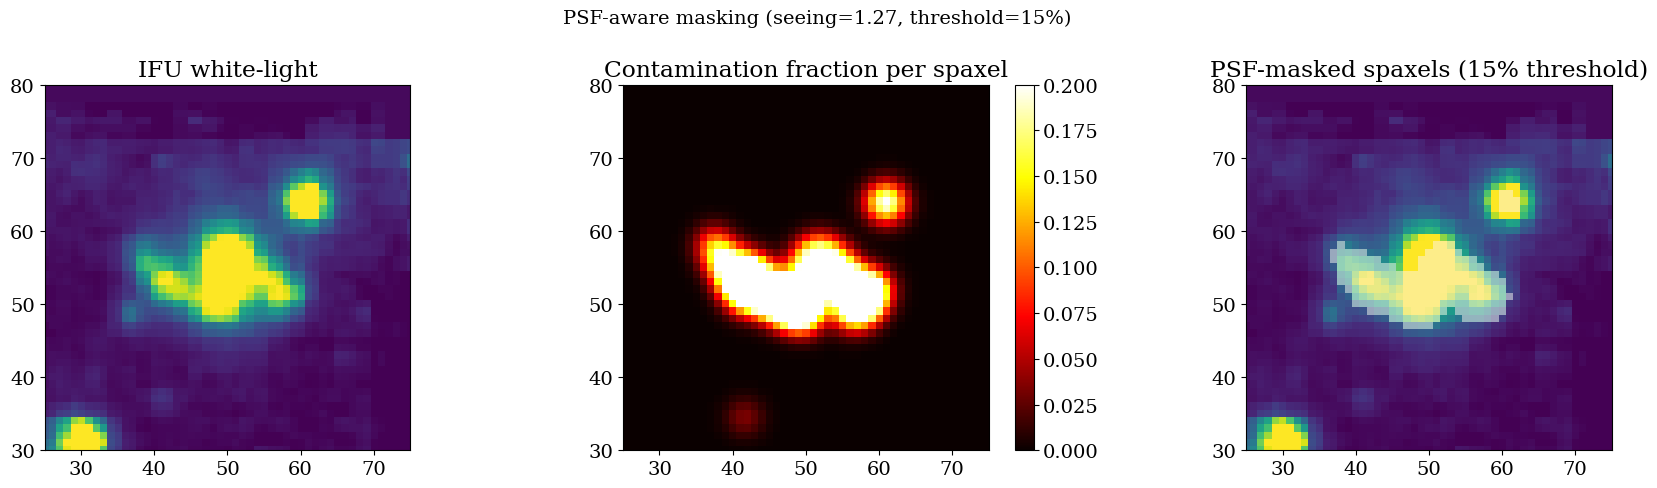

In [40]:
from scipy.ndimage import map_coordinates
# Reproject PSF-convolved contamination map onto IFU spaxel grid
# Use bilinear interpolation to sample the smooth contamination field
# at each IFU spaxel center position

wcs_ifu_2d = WCS(hdr, naxis=2)
yy_ifu, xx_ifu = np.mgrid[0:100, 0:100]
ra_ifu, dec_ifu = wcs_ifu_2d.pixel_to_world_values(xx_ifu.ravel(), yy_ifu.ravel())
x_hst_arr, y_hst_arr = wcs_cutout.world_to_pixel_values(ra_ifu, dec_ifu)
x_hst_arr = x_hst_arr.reshape(100, 100)
y_hst_arr = y_hst_arr.reshape(100, 100)

# Sample the convolved contamination map at IFU spaxel positions
spaxel_contamination = map_coordinates(mask_convolved,
                                       [y_hst_arr.ravel(), x_hst_arr.ravel()],
                                       order=1, mode="constant", cval=0.0)
spaxel_contamination = spaxel_contamination.reshape(100, 100)

# Flag spaxels above threshold
spaxel_masked_psf = spaxel_contamination > contamination_threshold
print(f"IFU spaxels flagged (PSF-aware): {np.sum(spaxel_masked_psf)} / {100*100}")
print(f"Previously (r=1 buffer): {np.sum(spaxel_masked)} / {100*100}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
wl_full = np.sum(cube, axis=0)

axes[0].imshow(wl_full, origin="lower", cmap="viridis",
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[0].set_title("IFU white-light")
axes[0].set_xlim(25, 75); axes[0].set_ylim(30, 80)

im1 = axes[1].imshow(spaxel_contamination, origin="lower", cmap="hot", vmin=0, vmax=0.2)
axes[1].set_title("Contamination fraction per spaxel")
axes[1].set_xlim(25, 75); axes[1].set_ylim(30, 80)
plt.colorbar(im1, ax=axes[1])

axes[2].imshow(wl_full, origin="lower", cmap="viridis",
               vmin=np.percentile(wl_full, 5), vmax=np.percentile(wl_full, 99))
axes[2].imshow(np.where(spaxel_masked_psf, 1, np.nan), origin="lower", cmap="Reds", alpha=0.5)
axes[2].set_title(f"PSF-masked spaxels ({100*contamination_threshold:.0f}% threshold)")
axes[2].set_xlim(25, 75); axes[2].set_ylim(30, 80)

plt.suptitle(f"PSF-aware masking (seeing={kcwi_seeing_fwhm}, threshold={100*contamination_threshold:.0f}%)", fontsize=14)
plt.tight_layout()
plt.show()


## Test 10: Sigma with PSF-aware masking at R_e apertures

In [41]:
# Re-run R_e aperture test with PSF-convolved mask
print(f"Sigma within circular apertures (PSF-aware mask, seeing={kcwi_seeing_fwhm} arcsec, thresh={100*contamination_threshold:.0f}%)")
print(f"{"Aperture":<30} {"N_all":>6} {"N_psf":>6} {"sig_all":>8} {"sig_psf":>8} {"delta":>7}")
print("-" * 70)

for label, r_max in apertures.items():
    mask_r = r_spax <= r_max
    n_all = np.sum(mask_r)
    clean_r = mask_r & ~spaxel_masked_psf
    n_clean = np.sum(clean_r)
    
    if n_all < 2 or n_clean < 2:
        print(f"{label:<30} {n_all:6d} {n_clean:6d}   (too few)")
        continue
    
    # Unmasked
    flux_all = np.average(cube[:, mask_r], axis=1)
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t2, f_a, n_a = lam_t[m], flux_all[m], noise[m]
    ll = np.log(lam_t2)
    dll = (ll[-1] - ll[0]) / (len(lam_t2) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    f_a = np.interp(lln, ll, f_a)
    n_a = np.interp(lln, ll, n_a)
    lam_t2 = np.exp(lln)
    m2 = (lam_t2 >= 6000) & (lam_t2 <= 7500)
    lam_t2, f_a, n_a = lam_t2[m2], f_a[m2], n_a[m2]
    gal = f_a / np.median(f_a)
    lg = np.copy(lam_t2)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr["DISPSCAL"] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {"lam": lr, "fwhm": fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    pp = ppxf(sp.templates, gal, np.sqrt(n_a**2), vs, [0, 300.],
              goodpixels=gp, plot=False, moments=2, trig=False,
              degree=20, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    sig_all = pp.sol[1]
    
    # PSF-masked
    flux_c = np.average(cube[:, clean_r], axis=1)
    lam_t3 = crval + cdelt * (pix + 1 - crpix)
    lam_t3, f_c, n_c = lam_t3[m], flux_c[m], noise[m]
    f_c = np.interp(lln, ll, f_c)
    n_c = np.interp(lln, ll, n_c)
    lam_t3 = np.exp(lln)
    lam_t3, f_c, n_c = lam_t3[m2], f_c[m2], n_c[m2]
    gal_c = f_c / np.median(f_c)
    pp_c = ppxf(sp.templates, gal_c, np.sqrt(n_c**2), vs, [0, 300.],
                goodpixels=gp, plot=False, moments=2, trig=False,
                degree=20, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    sig_psf = pp_c.sol[1]
    
    delta = sig_psf - sig_all
    print(f"{label:<30} {n_all:6d} {n_clean:6d} {sig_all:8.1f} {sig_psf:8.1f} {delta:+7.1f}")


Sigma within circular apertures (PSF-aware mask, seeing=1.27 arcsec, thresh=15%)
Aperture                        N_all  N_psf  sig_all  sig_psf   delta
----------------------------------------------------------------------
R < R_e/8 (0.33 arcsec)             5      0   (too few)
R < R_e/4 (0.65 arcsec)            13      1   (too few)
 Best Fit:       Vel     sigma
 comp.  0:        -8       223
chi2/DOF: 321.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        50       228
chi2/DOF: 1073.; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
R < R_e/2 (1.30 arcsec)            61     16    223.3    228.4    +5.1
 Best Fit:       Vel     sigma
 comp.  0:       -15       325
chi2/DOF: 477.7; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac

## Test 11: Approach A — Threshold sweep

Vary the contamination threshold from 5% to 50% and show how sigma
and N_clean change at each R_e aperture. Find the threshold where
the center has enough spaxels while the outer bins are still cleaned.

In [42]:
# Sweep contamination threshold at each aperture
thresholds = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

def quick_ppxf(flux_):
    """Run ppxf at degree=20 on a spectrum, return (sigma, V, chi2)."""
    noise = np.std(cube[:, 28:40, 45:70], axis=(1, 2))
    lam_t = crval + cdelt * (pix + 1 - crpix)
    m = (lam_t >= 6500) & (lam_t <= 7500)
    lam_t2, f_, n_ = lam_t[m], flux_[m], noise[m]
    ll = np.log(lam_t2)
    dll = (ll[-1] - ll[0]) / (len(lam_t2) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    f_ = np.interp(lln, ll, f_)
    n_ = np.interp(lln, ll, n_)
    lam_t2 = np.exp(lln)
    m2 = (lam_t2 >= 6000) & (lam_t2 <= 7500)
    lam_t2, f_, n_ = lam_t2[m2], f_[m2], n_[m2]
    gal = f_ / np.median(f_)
    lg = np.copy(lam_t2)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + 0.67511)
    fr = 2.355 * hdr["DISPSCAL"] * np.gradient(lg) / (1 + 0.67511)
    sp = lib.sps_lib(filename, vs, {"lam": lr, "fwhm": fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    pp = ppxf(sp.templates, gal, np.sqrt(n_**2), vs, [0, 300.],
              goodpixels=gp, plot=False, moments=2, trig=False,
              degree=20, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    return pp.sol[1], pp.sol[0], pp.chi2

aperture_labels = ["R<Re/8", "R<Re/4", "R<Re/2", "R<Re", "R<2Re"]
aperture_radii_list = [Re_8, Re/4, Re/2, Re, 2*Re]

# Build results table: [threshold][aperture] -> (n_clean, sigma)
results_sweep = {}
for thresh in thresholds:
    mask_t = spaxel_contamination > thresh
    row = []
    for r_max in aperture_radii_list:
        mask_r = r_spax <= r_max
        clean = mask_r & ~mask_t
        n_clean = np.sum(clean)
        if n_clean >= 3:
            flux_ = np.average(cube[:, clean], axis=1)
            sig, V, chi2 = quick_ppxf(flux_)
            row.append((n_clean, sig))
        else:
            row.append((n_clean, np.nan))
    results_sweep[thresh] = row

# Print table
header = f"  {'Thresh':>6}" + "".join(f"  {l:>14}" for l in aperture_labels)
print("Sigma at degree=20 for different thresholds and apertures:")
print(header)
print("-" * len(header))
for thresh in thresholds:
    row_str = f"  {thresh:6.0%}"
    for n, sig in results_sweep[thresh]:
        if np.isfinite(sig):
            row_str += f"  {n:3d} / {sig:5.0f}"
        else:
            row_str += f"  {n:3d} /   ---"
    print(row_str)
print("(format: N_clean / sigma)")


 Best Fit:       Vel     sigma
 comp.  0:        61       623
chi2/DOF: 7963.; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:      -154       682
chi2/DOF: 2.276e+04; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 23; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/387
 Best Fit:       Vel     sigma
 comp.  0:       105       263
chi2/DOF: 3912.; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        79       568
chi2/DOF: 3818.; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:      -167       668
chi2/DOF: 1.169e+0

## Test 12: Approach B — Contamination-weighted average

Instead of hard masking, weight each spaxel by `(1 - contamination_fraction)`.
Spaxels with 50% arc light get half weight; clean spaxels get full weight.
This uses all available information rather than discarding spaxels.

In [43]:
# Contamination-weighted spectrum averaging
# Weight = 1 - contamination_fraction (0 = fully contaminated, 1 = clean)

print("Contamination-weighted sigma (degree=20):")
print(f"{'Aperture':<30} {'N_spax':>6} {'sig_unweighted':>14} {'sig_weighted':>12} {'delta':>7}")
print("-" * 75)

for label, r_max in apertures.items():
    mask_r = r_spax <= r_max
    n_spax = np.sum(mask_r)
    if n_spax < 3:
        continue
    
    # Unweighted (simple average)
    flux_ = np.average(cube[:, mask_r], axis=1)
    sig_unw, _, _ = quick_ppxf(flux_)
    
    # Weighted: weight_i = 1 - contamination_i
    contam_vals = spaxel_contamination[mask_r]  # per-spaxel contamination
    weights = np.clip(1.0 - contam_vals, 0.01, 1.0)  # floor at 1%
    
    # Weighted average of spectra
    sub_cube = cube[:, mask_r]  # (n_wave, n_spax_in_aperture)
    flux_ = np.average(sub_cube, axis=1, weights=weights)
    sig_w, _, _ = quick_ppxf(flux_)
    
    delta = sig_w - sig_unw
    mean_w = np.mean(weights)
    print(f"{label:<30} {n_spax:6d} {sig_unw:14.1f} {sig_w:12.1f} {delta:+7.1f}  (mean weight: {mean_w:.2f})")


Contamination-weighted sigma (degree=20):
Aperture                       N_spax sig_unweighted sig_weighted   delta
---------------------------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:       -13       212
chi2/DOF: 827.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:       -13       212
chi2/DOF: 827.9; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
R < R_e/8 (0.33 arcsec)             5          211.6        212.1    +0.6  (mean weight: 0.76)
 Best Fit:       Vel     sigma
 comp.  0:        -4       214
chi2/DOF: 530.0; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     si

## Test 13: Summary comparison of all masking approaches

Compare at R < R_e/2 (the cleanest reliable aperture) and R < R_e:

In [44]:
# Summary at R_e/2 and R_e for all approaches
print("=" * 70)
print("MASKING APPROACH COMPARISON")
print("=" * 70)

for label, r_max in [("R < R_e/2", Re/2), ("R < R_e", Re)]:
    mask_r = r_spax <= r_max
    n_all = np.sum(mask_r)
    print(f"\n{label} ({r_max:.2f} arcsec, {n_all} total spaxels):")
    print(f"  {'Method':<40} {'N_used':>6} {'sigma':>7}")
    print(f"  {'-'*55}")
    
    # 1. No masking
    flux_ = np.average(cube[:, mask_r], axis=1)
    sig, _, _ = quick_ppxf(flux_)
    print(f"  {'No masking':<40} {n_all:6d} {sig:7.1f}")
    
    # 2. Hard mask r=1 buffer
    clean = mask_r & ~spaxel_masked
    n_c = np.sum(clean)
    if n_c >= 3:
        flux_ = np.average(cube[:, clean], axis=1)
        sig, _, _ = quick_ppxf(flux_)
        print(f"  {'Hard mask (r=1 pixel buffer)':<40} {n_c:6d} {sig:7.1f}")
    
    # 3. PSF mask at different thresholds
    for thresh in [0.15, 0.30, 0.50]:
        mask_t = spaxel_contamination > thresh
        clean = mask_r & ~mask_t
        n_c = np.sum(clean)
        if n_c >= 3:
            flux_ = np.average(cube[:, clean], axis=1)
            sig, _, _ = quick_ppxf(flux_)
            print(f"  {f'PSF mask (thresh={100*thresh:.0f}%)':<40} {n_c:6d} {sig:7.1f}")
        else:
            print(f"  {f'PSF mask (thresh={100*thresh:.0f}%)':<40} {n_c:6d}     ---")
    
    # 4. Contamination-weighted
    contam_vals = spaxel_contamination[mask_r]
    weights = np.clip(1.0 - contam_vals, 0.01, 1.0)
    flux_ = np.average(cube[:, mask_r], axis=1, weights=weights)
    sig, _, _ = quick_ppxf(flux_)
    print(f"  {'Contamination-weighted average':<40} {n_all:6d} {sig:7.1f}")

print("\n" + "=" * 70)


MASKING APPROACH COMPARISON

R < R_e/2 (1.30 arcsec, 61 total spaxels):
  Method                                   N_used   sigma
  -------------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:        -8       223
chi2/DOF: 321.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
  No masking                                   61   223.3
 Best Fit:       Vel     sigma
 comp.  0:        18       218
chi2/DOF: 480.5; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
  Hard mask (r=1 pixel buffer)                 36   218.4
 Best Fit:       Vel     sigma
 comp.  0:        50       228
chi2/DOF: 1073.; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
  PSF mas

## Test 14: Second velocity moment maps — V_rms = sqrt(V² + σ²)

Following Melo-Carneiro et al. (2025), map the second velocity moment
V_rms = sqrt(V² + σ²) which combines bulk rotation and random motions.
This is the kinematically relevant quantity for dynamical mass estimation.

Show maps from:
1. Annular radial bins (with and without masking)
2. Power bins
3. V_rms(R) radial profile

In [45]:
# Run ppxf on annular and power bins to get V and sigma
# Re-use the same ppxf procedure
from scipy.ndimage import gaussian_filter

# Center and radial grid
wcs_ifu_2d = WCS(hdr, naxis=2)
wl = np.sum(cube, axis=0)
wl_s = gaussian_filter(wl, sigma=2)
cy_pk, cx_pk = np.unravel_index(np.argmax(wl_s), wl_s.shape)

# Wide region
y_wide = slice(35, 75)
x_wide = slice(30, 70)
cube_wide = cube[:, y_wide, x_wide]
wl_wide = np.sum(cube_wide, axis=0)

# Peak in wide sub-image coords
dx_pk = cx_pk - x_wide.start
dy_pk = cy_pk - y_wide.start

# Radial distances for wide region
yy_w, xx_w = np.mgrid[y_wide.start:y_wide.stop, x_wide.start:x_wide.stop]
ra_w, dec_w = wcs_ifu_2d.pixel_to_world_values(xx_w.ravel(), yy_w.ravel())
ra_c, dec_c = wcs_ifu_2d.pixel_to_world_values(cx_pk, cy_pk)
dra_w = (ra_w.reshape(40,40) - ra_c) * np.cos(np.radians(dec_c)) * 3600
ddec_w = (dec_w.reshape(40,40) - dec_c) * 3600
r_w = np.sqrt(dra_w**2 + ddec_w**2)

# Contamination map for the wide region
contam_wide = spaxel_contamination[y_wide, x_wide]
mask_wide = spaxel_masked_psf[y_wide, x_wide]

# Noise
noise_sky = np.std(cube[:, 28:40, 45:70], axis=(1, 2))

print(f"Wide region: {cube_wide.shape[1]}x{cube_wide.shape[2]}")
print(f"Center: ({dx_pk}, {dy_pk}) in sub-image")


Wide region: 40x40
Center: (20, 20) in sub-image


In [46]:
# Annular bins: get V and sigma (unmasked and masked)
r_edges = np.arange(0, 4.5, 0.5)  # out to 4 arcsec

ann_results_unmask = []  # (r_mid, V, sigma, V_rms, n_spax)
ann_results_mask = []
ann_results_weighted = []

for j in range(len(r_edges) - 1):
    r_lo, r_hi = r_edges[j], r_edges[j+1]
    r_mid = (r_lo + r_hi) / 2
    mask_ann = (r_w >= r_lo) & (r_w < r_hi)
    n_all = np.sum(mask_ann)
    if n_all < 3:
        continue
    
    # Unmasked
    flux_ = np.average(cube_wide[:, mask_ann], axis=1)
    sig, V, chi2 = quick_ppxf(flux_)
    vrms = np.sqrt(V**2 + sig**2)
    ann_results_unmask.append((r_mid, V, sig, vrms, n_all))
    
    # Hard masked
    clean = mask_ann & ~mask_wide
    n_clean = np.sum(clean)
    if n_clean >= 3:
        flux_ = np.average(cube_wide[:, clean], axis=1)
        sig_m, V_m, _ = quick_ppxf(flux_)
        vrms_m = np.sqrt(V_m**2 + sig_m**2)
        ann_results_mask.append((r_mid, V_m, sig_m, vrms_m, n_clean))
    
    # Contamination-weighted
    weights = np.clip(1.0 - contam_wide[mask_ann], 0.01, 1.0)
    flux_ = np.average(cube_wide[:, mask_ann], axis=1, weights=weights)
    sig_w, V_w, _ = quick_ppxf(flux_)
    vrms_w = np.sqrt(V_w**2 + sig_w**2)
    ann_results_weighted.append((r_mid, V_w, sig_w, vrms_w, n_all))

print(f"Annular bins: {len(ann_results_unmask)} unmasked, {len(ann_results_mask)} masked, {len(ann_results_weighted)} weighted")

# Print table
print(f"\n{'R (arcsec)':>10} {'V':>7} {'sigma':>7} {'V_rms':>7} | {'V_m':>7} {'sig_m':>7} {'Vrms_m':>7} | {'V_w':>7} {'sig_w':>7} {'Vrms_w':>7}")
print(f"{'':<10} {'--- unmasked ---':^21} | {'--- masked ---':^21} | {'--- weighted ---':^21}")
print("-" * 80)
for i, (r, V, sig, vrms, n) in enumerate(ann_results_unmask):
    row = f"{r:10.2f} {V:7.0f} {sig:7.0f} {vrms:7.0f}"
    if i < len(ann_results_mask):
        _, Vm, sm, vrm, _ = ann_results_mask[i]
        row += f" | {Vm:7.0f} {sm:7.0f} {vrm:7.0f}"
    else:
        row += " |     ---     ---     ---"
    if i < len(ann_results_weighted):
        _, Vw, sw, vrw, _ = ann_results_weighted[i]
        row += f" | {Vw:7.0f} {sw:7.0f} {vrw:7.0f}"
    print(row)


 Best Fit:       Vel     sigma
 comp.  0:        -4       218
chi2/DOF: 677.7; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:        -5       219
chi2/DOF: 678.2; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -25       205
chi2/DOF: 442.3; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        34       212
chi2/DOF: 1307.; DOF: 925; degree = 20; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -22       206
chi2/DOF: 464.1; DOF: 

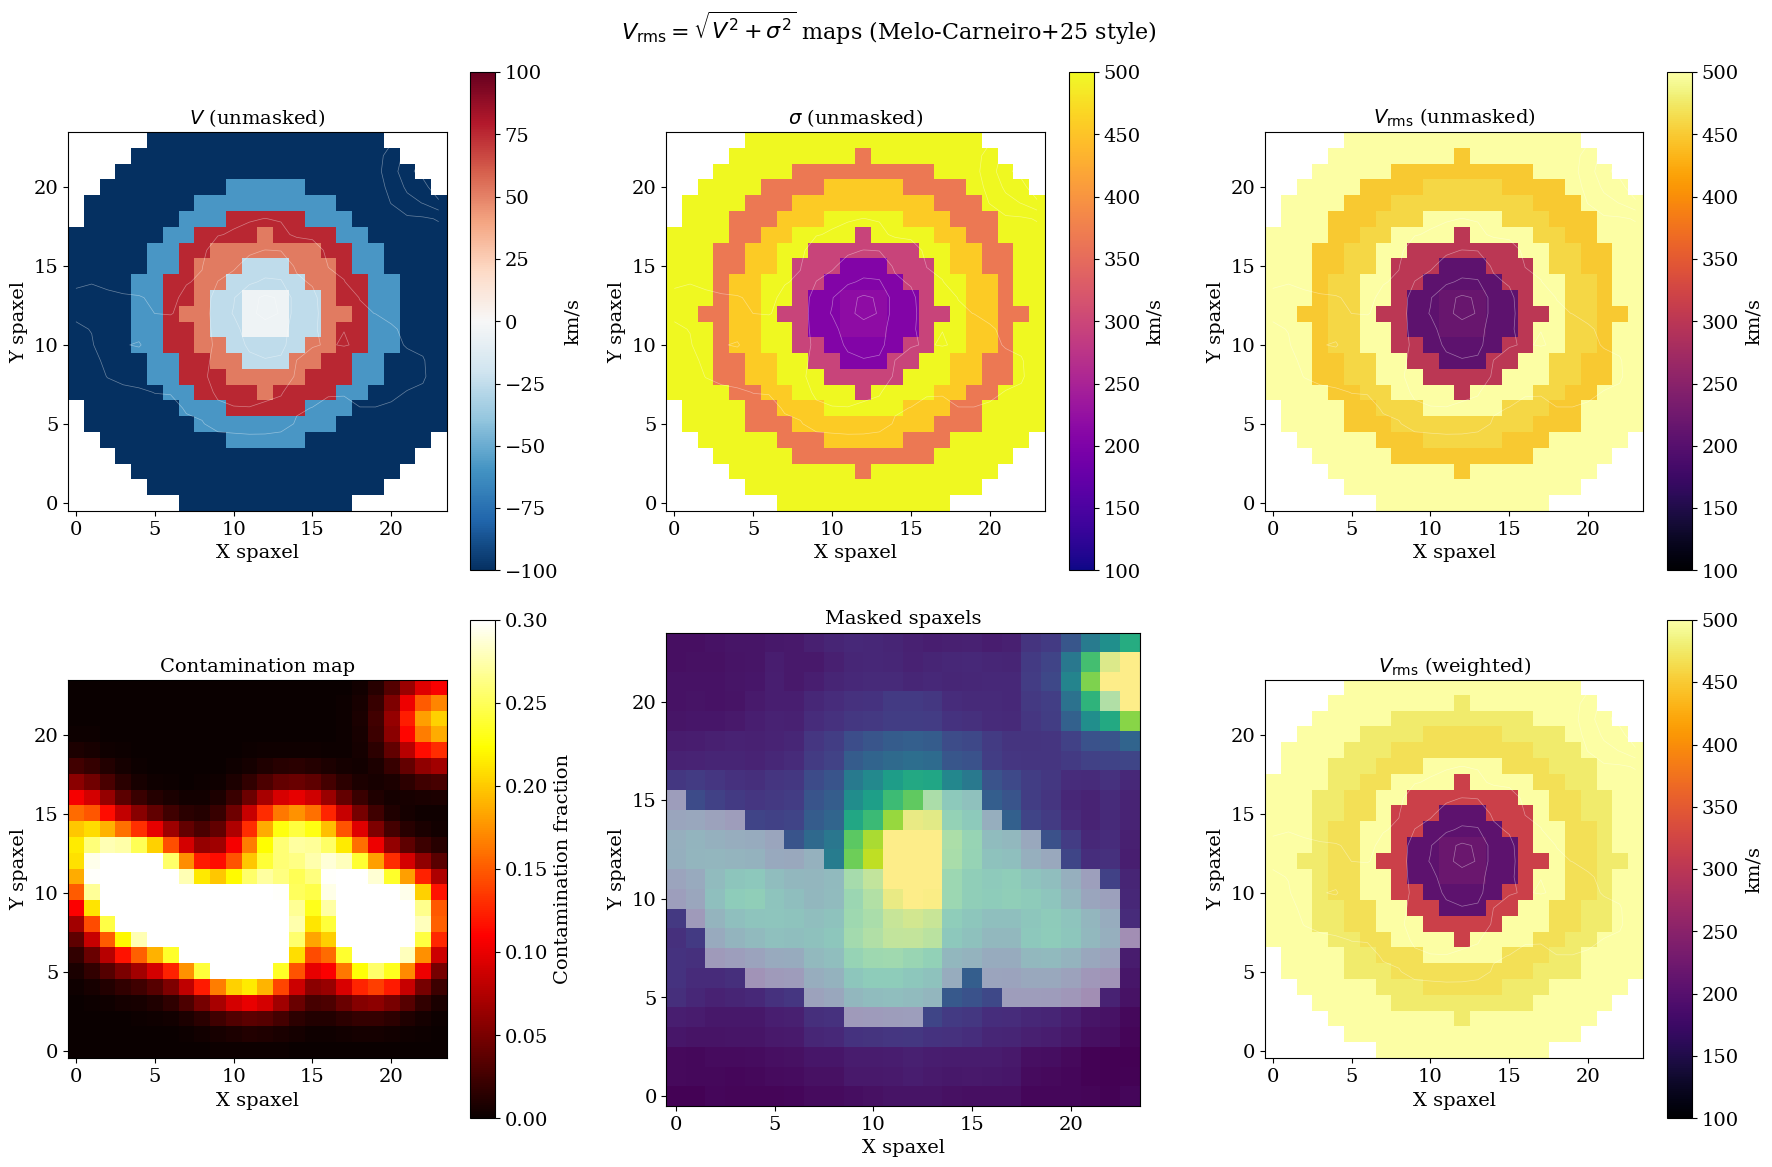

In [47]:
# Build 2D V_rms maps
from matplotlib.patches import Circle

# Annular V_rms map (unmasked)
vrms_map_unmask = np.full(wl_wide.shape, np.nan)
sigma_map_unmask = np.full(wl_wide.shape, np.nan)
V_map_unmask = np.full(wl_wide.shape, np.nan)
for r_mid, V, sig, vrms, n in ann_results_unmask:
    r_lo = r_mid - 0.25
    r_hi = r_mid + 0.25
    mask_ann = (r_w >= r_lo) & (r_w < r_hi)
    vrms_map_unmask[mask_ann] = vrms
    sigma_map_unmask[mask_ann] = sig
    V_map_unmask[mask_ann] = V

# Annular V_rms map (weighted)
vrms_map_weighted = np.full(wl_wide.shape, np.nan)
for r_mid, V, sig, vrms, n in ann_results_weighted:
    r_lo = r_mid - 0.25
    r_hi = r_mid + 0.25
    mask_ann = (r_w >= r_lo) & (r_w < r_hi)
    vrms_map_weighted[mask_ann] = vrms

# Plot: 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: unmasked
titles_top = [r"$V$ (unmasked)", r"$\sigma$ (unmasked)", r"$V_{\rm rms}$ (unmasked)"]
maps_top = [V_map_unmask, sigma_map_unmask, vrms_map_unmask]
cmaps_top = ["RdBu_r", "plasma", "inferno"]
vlims_top = [(-100, 100), (100, 500), (100, 500)]

for ax, title, data, cmap, (vmin, vmax) in zip(axes[0], titles_top, maps_top, cmaps_top, vlims_top):
    delta = 12
    y1, y2 = max(0, dy_pk-delta), min(40, dy_pk+delta)
    x1, x2 = max(0, dx_pk-delta), min(40, dx_pk+delta)
    im = ax.imshow(data[y1:y2, x1:x2], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.contour(wl_wide[y1:y2, x1:x2], levels=5, colors="white", alpha=0.4, linewidths=0.5)
    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax, label="km/s")

# Bottom row: contamination-weighted
titles_bot = [r"Contamination map", r"Masked spaxels", r"$V_{\rm rms}$ (weighted)"]
im3 = axes[1][0].imshow(contam_wide[y1:y2, x1:x2], origin="lower", cmap="hot", vmin=0, vmax=0.3)
axes[1][0].set_title(titles_bot[0], fontsize=14)
plt.colorbar(im3, ax=axes[1][0], label="Contamination fraction")

axes[1][1].imshow(wl_wide[y1:y2, x1:x2], origin="lower", cmap="viridis",
                  vmin=np.percentile(wl_wide, 5), vmax=np.percentile(wl_wide, 99))
axes[1][1].imshow(np.where(mask_wide[y1:y2, x1:x2], 1, np.nan),
                  origin="lower", cmap="Reds", alpha=0.5)
axes[1][1].set_title(titles_bot[1], fontsize=14)

im5 = axes[1][2].imshow(vrms_map_weighted[y1:y2, x1:x2], origin="lower",
                        cmap="inferno", vmin=100, vmax=500)
axes[1][2].contour(wl_wide[y1:y2, x1:x2], levels=5, colors="white", alpha=0.4, linewidths=0.5)
axes[1][2].set_title(titles_bot[2], fontsize=14)
plt.colorbar(im5, ax=axes[1][2], label="km/s")

for ax in axes.ravel():
    ax.set_xlabel("X spaxel")
    ax.set_ylabel("Y spaxel")

plt.suptitle(r"$V_{\rm rms} = \sqrt{V^2 + \sigma^2}$ maps (Melo-Carneiro+25 style)", fontsize=16)
plt.tight_layout()
plt.show()


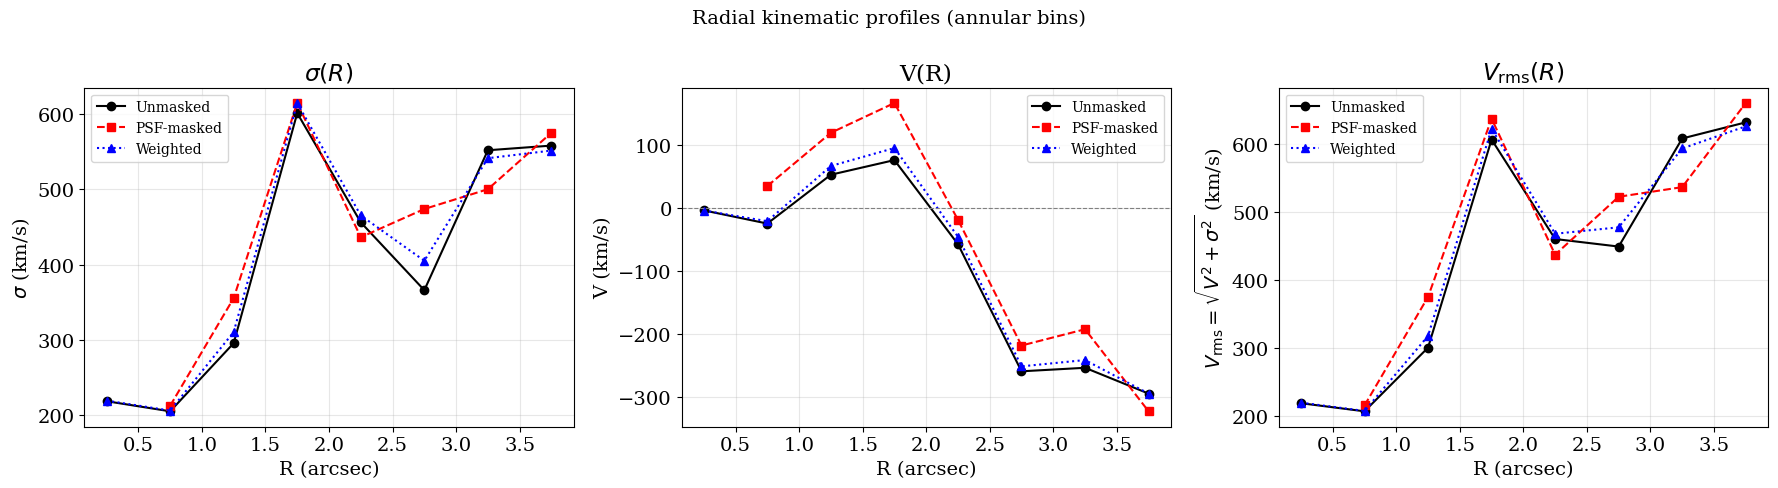

In [48]:
# V_rms radial profile: all three approaches
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Unpack arrays
r_u = [x[0] for x in ann_results_unmask]
V_u = [x[1] for x in ann_results_unmask]
sig_u = [x[2] for x in ann_results_unmask]
vrms_u = [x[3] for x in ann_results_unmask]

r_m = [x[0] for x in ann_results_mask]
vrms_m = [x[3] for x in ann_results_mask]
sig_m = [x[2] for x in ann_results_mask]
V_m = [x[1] for x in ann_results_mask]

r_wt = [x[0] for x in ann_results_weighted]
vrms_wt = [x[3] for x in ann_results_weighted]

# Left: sigma(R)
ax = axes[0]
ax.plot(r_u, sig_u, "ko-", markersize=6, label="Unmasked")
ax.plot(r_m, sig_m, "rs--", markersize=6, label="PSF-masked")
ax.plot(r_wt, [x[2] for x in ann_results_weighted], "b^:", markersize=6, label="Weighted")
ax.set_xlabel("R (arcsec)")
ax.set_ylabel(r"$\sigma$ (km/s)")
ax.set_title(r"$\sigma(R)$")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Middle: V(R)
ax = axes[1]
ax.plot(r_u, V_u, "ko-", markersize=6, label="Unmasked")
ax.plot(r_m, V_m, "rs--", markersize=6, label="PSF-masked")
ax.plot(r_wt, [x[1] for x in ann_results_weighted], "b^:", markersize=6, label="Weighted")
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("R (arcsec)")
ax.set_ylabel("V (km/s)")
ax.set_title("V(R)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: V_rms(R)
ax = axes[2]
ax.plot(r_u, vrms_u, "ko-", markersize=6, label="Unmasked")
ax.plot(r_m, vrms_m, "rs--", markersize=6, label="PSF-masked")
ax.plot(r_wt, vrms_wt, "b^:", markersize=6, label="Weighted")
ax.set_xlabel("R (arcsec)")
ax.set_ylabel(r"$V_{\rm rms} = \sqrt{V^2 + \sigma^2}$ (km/s)")
ax.set_title(r"$V_{\rm rms}(R)$")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle("Radial kinematic profiles (annular bins)", fontsize=14)
plt.tight_layout()
plt.show()


## Test 15: Bootstrap errors on V_rms radial profile

Run N=100 bootstrap on each annular bin (contamination-weighted)
using EMILES templates at degrees 15-25. Report 16th/84th percentile
errors on V, sigma, and V_rms = sqrt(V² + σ²).

In [ ]:
# Bootstrap V_rms errors on the contamination-weighted annular bins
from scipy.ndimage import uniform_filter1d

N_BOOT = 100
sps_name_boot = "emiles"
degrees_boot = np.arange(15, 26)  # 15-25

def bootstrap_vrms_bin(flux_in, noise_in, n_bootstrap=100, seed=42):
    """Bootstrap V, sigma, V_rms for one radial bin spectrum."""
    c_kms = 299792.458
    z = 0.67511
    
    # Prep spectrum (same as quick_ppxf but for emiles)
    mask_wl = (lam >= 6500) & (lam <= 7500)
    lam_t = lam[mask_wl]
    f_t = flux_in[mask_wl]
    n_t = noise_in[mask_wl]
    ll = np.log(lam_t)
    dll = (ll[-1] - ll[0]) / (len(lam_t) - 1)
    lln = np.arange(ll[0], ll[-1] + dll, dll)
    f_t = np.interp(lln, ll, f_t)
    n_t = np.interp(lln, ll, n_t)
    lam_r = np.exp(lln)
    m2 = (lam_r >= 6000) & (lam_r <= 7500)
    lam_r, f_t, n_t = lam_r[m2], f_t[m2], n_t[m2]
    
    if np.median(f_t) <= 0:
        return None
    
    galaxy = f_t / np.median(f_t)
    noise_norm = np.sqrt(n_t**2) / np.median(f_t)
    lg = np.copy(lam_r)
    lg *= np.median(util.vac_to_air(lg) / lg)
    vs = c_kms * (np.log(lg)[-1] - np.log(lg)[0]) / (len(lg) - 1)
    lr = lg / (1 + z)
    fr = 2.355 * hdr["DISPSCAL"] * np.gradient(lg) / (1 + z)
    
    ppxf_dir = resources.files("ppxf")
    fn = ppxf_dir / "sps_models" / f"spectra_{sps_name_boot}_9.0.npz"
    sp = lib.sps_lib(fn, vs, {"lam": lr, "fwhm": fr}, lam_range=[3500, 5000])
    gp = util.determine_goodpixels(np.log(lr), [3500, 5000])
    
    # Initial fit at median degree to get best-fit + residuals
    deg_mid = int(np.median(degrees_boot))
    pp0 = ppxf(sp.templates, galaxy, noise_norm, vs, [0, 300.],
              goodpixels=gp, plot=False, moments=2, trig=False,
              degree=deg_mid, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
    bestfit = pp0.bestfit
    resid = galaxy - bestfit
    
    # Local residual scaling
    g_std = np.std(resid)
    if g_std > 0:
        loc_mean = uniform_filter1d(resid, size=75, mode="reflect")
        loc_sq = uniform_filter1d(resid**2, size=75, mode="reflect")
        loc_var = np.maximum(loc_sq - loc_mean**2, 0)
        scale = np.clip(np.sqrt(loc_var) / g_std, 0.2, 5.0)
    else:
        scale = np.ones_like(resid)
    scaled_resid = resid * scale
    
    # Bootstrap
    rng = np.random.default_rng(seed)
    V_samp = np.full(n_bootstrap, np.nan)
    sig_samp = np.full(n_bootstrap, np.nan)
    vrms_samp = np.full(n_bootstrap, np.nan)
    
    for i in range(n_bootstrap):
        signs = rng.choice([-1, 1], size=len(galaxy))
        gal_boot = bestfit + scaled_resid * signs
        try:
            pp = ppxf(sp.templates, gal_boot, noise_norm, vs, [0, 300.],
                      goodpixels=gp, plot=False, moments=2, trig=False,
                      degree=deg_mid, lam=lr, lam_temp=sp.lam_temp, mdegree=0)
            V_samp[i] = pp.sol[0]
            sig_samp[i] = pp.sol[1]
            vrms_samp[i] = np.sqrt(pp.sol[0]**2 + pp.sol[1]**2)
        except Exception:
            pass
    
    valid_s = sig_samp[np.isfinite(sig_samp)]
    valid_v = V_samp[np.isfinite(V_samp)]
    valid_vr = vrms_samp[np.isfinite(vrms_samp)]
    
    if len(valid_s) < 5:
        return None
    
    return {
        "sig_p16": np.percentile(valid_s, 16),
        "sig_p50": np.percentile(valid_s, 50),
        "sig_p84": np.percentile(valid_s, 84),
        "V_p16": np.percentile(valid_v, 16),
        "V_p50": np.percentile(valid_v, 50),
        "V_p84": np.percentile(valid_v, 84),
        "vrms_p16": np.percentile(valid_vr, 16),
        "vrms_p50": np.percentile(valid_vr, 50),
        "vrms_p84": np.percentile(valid_vr, 84),
        "n_valid": len(valid_s),
    }

print(f"Bootstrap: N={N_BOOT}, templates={sps_name_boot}, degrees={degrees_boot[0]}-{degrees_boot[-1]}")
print(f"Running on contamination-weighted annular bins...")

boot_vrms = []
for j in range(len(r_edges) - 1):
    r_lo, r_hi = r_edges[j], r_edges[j+1]
    r_mid = (r_lo + r_hi) / 2
    mask_ann = (r_w >= r_lo) & (r_w < r_hi)
    n_all = np.sum(mask_ann)
    if n_all < 3:
        continue
    
    # Contamination-weighted spectrum
    weights = np.clip(1.0 - contam_wide[mask_ann], 0.01, 1.0)
    flux_w = np.average(cube_wide[:, mask_ann], axis=1, weights=weights)
    
    print(f"  R={r_mid:.2f} arcsec ({n_all} spaxels)...", end=" ")
    b = bootstrap_vrms_bin(flux_w, noise_sky, n_bootstrap=N_BOOT, seed=42+j)
    if b is not None:
        b["r_mid"] = r_mid
        b["n_spax"] = n_all
        boot_vrms.append(b)
        print(f"sig={b['sig_p50']:.0f} -{b['sig_p50']-b['sig_p16']:.0f}/+{b['sig_p84']-b['sig_p50']:.0f}, "
              f"V={b['V_p50']:.0f}, Vrms={b['vrms_p50']:.0f} -{b['vrms_p50']-b['vrms_p16']:.0f}/+{b['vrms_p84']-b['vrms_p50']:.0f}")
    else:
        print("failed")


In [ ]:
# Plot V_rms(R) with bootstrap error bars
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

r_b = [b["r_mid"] for b in boot_vrms]

# sigma(R)
ax = axes[0]
sig_med = [b["sig_p50"] for b in boot_vrms]
sig_lo = [b["sig_p50"] - b["sig_p16"] for b in boot_vrms]
sig_hi = [b["sig_p84"] - b["sig_p50"] for b in boot_vrms]
ax.errorbar(r_b, sig_med, yerr=[sig_lo, sig_hi], fmt="o-", color="C0",
            capsize=4, markersize=7, lw=2, label=f"{sps_name_boot} (weighted)")
ax.set_xlabel("R (arcsec)")
ax.set_ylabel(r"$\sigma$ (km/s)")
ax.set_title(r"$\sigma(R)$ with bootstrap errors")
ax.legend()
ax.grid(alpha=0.3)

# V(R)
ax = axes[1]
V_med = [b["V_p50"] for b in boot_vrms]
V_lo = [b["V_p50"] - b["V_p16"] for b in boot_vrms]
V_hi = [b["V_p84"] - b["V_p50"] for b in boot_vrms]
ax.errorbar(r_b, V_med, yerr=[V_lo, V_hi], fmt="s-", color="C1",
            capsize=4, markersize=7, lw=2)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("R (arcsec)")
ax.set_ylabel("V (km/s)")
ax.set_title("V(R) with bootstrap errors")
ax.grid(alpha=0.3)

# V_rms(R)
ax = axes[2]
vrms_med = [b["vrms_p50"] for b in boot_vrms]
vrms_lo = [b["vrms_p50"] - b["vrms_p16"] for b in boot_vrms]
vrms_hi = [b["vrms_p84"] - b["vrms_p50"] for b in boot_vrms]
ax.errorbar(r_b, vrms_med, yerr=[vrms_lo, vrms_hi], fmt="D-", color="C3",
            capsize=4, markersize=7, lw=2)
ax.set_xlabel("R (arcsec)")
ax.set_ylabel(r"$V_{\rm rms} = \sqrt{V^2 + \sigma^2}$ (km/s)")
ax.set_title(r"$V_{\rm rms}(R)$ with bootstrap errors")
ax.grid(alpha=0.3)

plt.suptitle(f"Bootstrap kinematic profiles (N={N_BOOT}, {sps_name_boot}, deg {degrees_boot[0]}-{degrees_boot[-1]}, weighted)", fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'R (arcsec)':>10} {'N':>5} {'sigma':>17} {'V':>17} {'V_rms':>17}")
print("-" * 70)
for b in boot_vrms:
    print(f"{b['r_mid']:10.2f} {b['n_spax']:5d} "
          f"{b['sig_p50']:5.0f} -{b['sig_p50']-b['sig_p16']:4.0f}/+{b['sig_p84']-b['sig_p50']:4.0f}  "
          f"{b['V_p50']:5.0f} -{b['V_p50']-b['V_p16']:4.0f}/+{b['V_p84']-b['V_p50']:4.0f}  "
          f"{b['vrms_p50']:5.0f} -{b['vrms_p50']-b['vrms_p16']:4.0f}/+{b['vrms_p84']-b['vrms_p50']:4.0f}")
